# OccPy tutorial notebook for Mobile Laser Scanning (MLS) data

This notebook gives a brief overview over MLS occlusion mapping using OccPy.
The data used for this analysis were acquired using a GeoSLAM ZebHorizon handheld MLS in the Rameren forest close to the WSL in Birmensdorf, Switzerland. The forest plot is characterized as a mixed temperate forest and the data was acquired under leaf-on conditions. The data has been heavily filtered to reduce storage needs and reduce processing time. The tutorial data is the same as used for the manuscript currently under revision in RSE and available as pre-print here: (TODO!)
OccPy can be controlled through a JSON settings file, where all necessary settings are defined for a successful execution of OccPy

First we download the test data and look for the OccPy root folder on your system. All following paths depend on this root directory. 
We further have a look into the JSON settings file to look at its structure

In [2]:
import json
import os
from pathlib import Path
import pooch

# get OccPy root directory
def find_project_root(markers=('README.md','.gitignore','environment.yml','setup.py')):
    try:
        import ipynbname
        current = ipynbname.path().parent
    except Exception:
        current = Path(os.getcwd())

    for parent in [current, *current.parents]:
        if any((parent / m).exists() for m in markers):
            return parent
        
    return current # fallback if nothing found

# Download test data
p = pooch.create(
    path=pooch.os_cache("occpy_test_data_mls"),
    base_url="https://zenodo.org/records/17750604/files/",
    registry={"MLS_demo.zip": "md5:1ed22572cd90768ea4ab9a34e9c70c62"},
)
p.fetch("MLS_demo.zip", processor=pooch.Unzip(members=["MLS_demo"]), progressbar=True)
data_path = os.path.join(p.path, "MLS_demo.zip.unzip", "MLS_demo")
print(data_path)

occpy_root = find_project_root()
print("Detected occpy root:", occpy_root)

# Load the JSON file
with open(os.path.join(occpy_root, 'config', 'settings_MLS_tutorial.JSON'), 'r') as file:
    settings_orig = json.load(file)
# Display the settings
settings_orig

100%|██████████████████████████████████████| 56.2M/56.2M [00:00<00:00, 143GB/s]
Extracting 'MLS_demo' from '/Users/danielkukenbrink/Library/Caches/occpy_test_data_mls/MLS_demo.zip' to '/Users/danielkukenbrink/Library/Caches/occpy_test_data_mls/MLS_demo.zip.unzip'


/Users/danielkukenbrink/Library/Caches/occpy_test_data_mls/MLS_demo.zip.unzip/MLS_demo
Detected occpy root: /Users/danielkukenbrink/dev/OccPy


{'root_folder': 'f:\\Projects\\3DForEcoTech\\WG_1_OcclusionMapping\\OcclusionMapping_Examples\\OccPy',
 'laz_in': 'data/MLS/MLS_TestData_20perc_FP10_2025.laz',
 'tif_in': {'DTM': 'data/Grids/Ramerenwald_DTM_20250305.tif',
  'DSM': 'data/Grids/Ramerenwald_DSM_20250305.tif'},
 'out_dir': 'output\\MLS',
 'vox_dim': 0.1,
 'lower_threshold': 1,
 'points_per_iter': 1000000,
 'plot_dim': [2676515, 1246063, 545, 2676525, 1246113, 590],
 'ScanPos': 'data/MLS/MLS_TestData_traj_FP10_2025.txt',
 'output_voxels': False}

This JSON file can either be modified using your text editor of choice or you could load it into python using the json package and alter the variables within the script, as shown in the following code snippet.
Here is an explanation for the various settings:
- root_folder: root folder of where OccPy is installed -> actually not necessary anymore and can be blank
- laz_in: input laz file - In this case we are expecting a single laz file. If you have multiple laz file (e.g. when using multiple TLS scans), this could be also a directory. See TLS_notebook.ipynb notebook for this case
- tif_in[DTM]: Optional input defining a digital terrain model as a tif file. This is used later for normalization of the output
- tif_in[DSM]: Optional input defining a digital surface model as a tifl file. This is only used in order to give a restriction, until where the canopy is going and will cut off everything above. If this is not needed, you can leave this specification empty. 
        For both surface models: if the extent and resolution does not match the provided plot_dim, it will be cut and transformed to match the voxel grid dimension. It would also expand the terrain/surface models, but I would recommend to always provide a terrain/surface model that is larger in extent than the defined plot_dim
- out_dir: output directory where the output .npy files are stored
- vox_din: voxel size - currently this applies to x, y, and z dimension. Non-cubic voxels are on the list of features to be added
- lower_threshold: height, below which the output will be cut. This can be used to get rid of ground effect on the outputs. 
- points_per_iter: how many points should be loaded in one go. 
- plot_dim: plot dimensions in the format [min_x, min_y, min_z, max_x, max_y, max_z]
- ScanPos: path to the trajectory information (or scan position information for TLS)
- output_voxels: [True/False] if the output should be outputted as ply files - currently not working properly.

In [3]:
import json
import os

# copy original settings file 
settings = settings_orig.copy()
# alter root folder
settings['root_folder'] = os.path.abspath(occpy_root)
# update input paths to be relative to the root folder
settings['laz_in'] = os.path.join(data_path, 'LAZ', 'MLS_TestData_20perc_FP10_2025.laz')
settings['tif_in']['DTM'] = os.path.join(data_path, 'Grids', 'Ramerenwald_DTM_20250305.tif')
settings['tif_in']['DSM'] = os.path.join(data_path, 'Grids', 'Ramerenwald_DSM_20250305.tif')
settings['ScanPos'] = os.path.join(data_path, 'ScanPos', 'MLS_TestData_traj_FP10_2025.txt')
settings['out_dir'] = os.path.join(settings['root_folder'], 'output', 'MLS')


# Save the modified settings back to the JSON file
with open(os.path.join(occpy_root, 'config', 'settings_MLS_tutorial_adapt.JSON'), 'w') as file:
    print(file)
    json.dump(settings, file, indent=4)


<_io.TextIOWrapper name='/Users/danielkukenbrink/dev/OccPy/config/settings_MLS_tutorial_adapt.JSON' mode='w' encoding='UTF-8'>


With the settings JSON file all setup, we are now ready to run OccPy on the provided data.
First we have load the OccPy package


In [4]:
from occpy.OccPy import OccPy

RIEGL RDBlib is not available
RIEGL RiVlib is not available


We first load the json file (this is actually not needed anymore, as we have already done this before, but just to be sure, we have the actual settings)

In [5]:
def load_config(config_file):
    """Load the configuration from the JSON file."""
    with open(config_file, 'r') as file:
        config = json.load(file)
    return config

config_file = os.path.join(occpy_root, 'config', 'settings_MLS_tutorial_adapt.JSON') 
config = load_config(config_file)


Now we create an instance of the OccPy Class and prepare it for the voxel traversal 

In [6]:
test = OccPy(laz_in=f"{config['laz_in']}",
             out_dir=config['out_dir'],
             vox_dim=config['vox_dim'],
             lower_threshold=config['lower_threshold'],
             points_per_iter=config['points_per_iter'],
             plot_dim=config['plot_dim'],)

Now we have to read in the trajectory information

In [7]:
test.define_sensor_pos(path2file=config['ScanPos'],         # Path to the trajectory file
                       is_mobile=True,                      # whether acquisition is mobile. Always true for MLS or ULS
                       single_return=True,                  # wheter the data is single or multi return
                       delimiter=" ",                       # delimiter used in the trajectory file 
                       hdr_time='//world_time',             # column header for the time information in the trajectory file
                       hdr_x='x',                           # column header for the x coordinate in the trajectory file
                       hdr_y='y',                           # column header for the y coordinate in the trajectory file
                       hdr_z='z',)                          # column header for the z coordinate in the trajectory file


Now we can start the raytracing and save the outputs.

In [8]:
import time
tic = time.time()
test.do_raytracing()
toc = time.time()
print(f"Raytracing took {toc - tic:.2f} seconds.")

Tracing Pulses...: 100%|██████████| 5680089/5680089 [00:06<00:00, 880075.74pulses/s]


Extracting Nhit
#### 2981545 Pulses were traversed of possible 5680089 Pulses
#### 919306 Returns have been registered by the algorithm 
#### 2062238 Returns were found outside the voxel grid 
#### 0 Returns were missed during the traversal!
#### 2698544 Pulses did not intersect voxel grid!
Elapsed Time: 0.66 seconds
Extracting Nocc
Elapsed Time: 0.54 seconds
Extracting Nmiss
Elapsed Time: 0.64 seconds
Saving Occlusion Outputs As .npy
Elapsed Time: 0.04 seconds
Classify Grid
Elapsed Time: 0.14570212364196777 seconds
Raytracing took 8.49 seconds.


We can now height normalize the outputs using the provided DTM and DSM file. The DSM file is only to define the upper bounds of the canopy. Function 'normalize_occlusion_output' will also store the normalized voxel grids as npy files in the specified output folder

In [10]:
from occpy.util import normalize_occlusion_output

Nhit_norm, Nmiss_norm, Nocc_norm, Classification_norm, chm = normalize_occlusion_output(input_folder=config['out_dir'],
                                                                                        PlotDim=config['plot_dim'],
                                                                                        vox_dim=config['vox_dim'],
                                                                                        dtm_file=config['tif_in']['DTM'],
                                                                                        dsm_file=config['tif_in']['DSM'],
                                                                                        lower_threshold=config['lower_threshold'],
                                                                                        output_voxels=config['output_voxels'])

# If instead of a binary voxel grid classification, you are intereded in a fraction of occluded pulses per voxel, you can use the following function:
OcclFrac_norm = Nocc_norm.astype(float) / (Nhit_norm.astype(float) + Nmiss_norm.astype(float) + Nocc_norm.astype(float))


Saving normalized output files into directory as .npy...


/var/folders/l_/r_d39hmx7l3b1df2zbgd6qbc0000gn/T/ipykernel_15430/2554475173.py:12: RuntimeWarning: invalid value encountered in divide
  OcclFrac_norm = Nocc_norm.astype(float) / (Nhit_norm.astype(float) + Nmiss_norm.astype(float) + Nocc_norm.astype(float))


We can also visualize the results. Note that there is a lot of occlusion shown in this example. This is caused by the havy filtering performed to reduce data size of this example dataset.

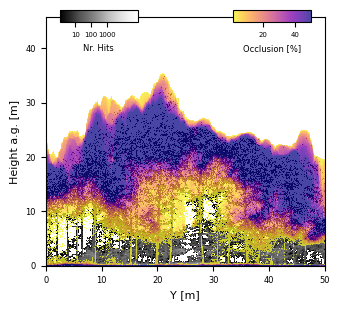

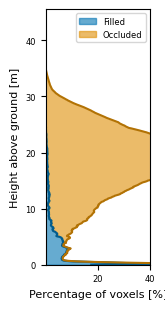

In [11]:
from occpy.visualization import get_Occl_TransectFigure_BinaryOcclusion

# first define figure properties
fig_prop = dict(fig_size=(3.5, 3.2),        # figure size in inches
                label_size=8,               # label size in pts. for e.g. axis labels
                label_size_ticks=6,         # label size in pts. for e.g. axis ticks
                label_size_tiny=5,          # label size in pts. for e.g. ticks in colorbar
                out_format='png',)          # output format of the figure, can be 'png', 'pdf', 'svg', etc.

%matplotlib inline
get_Occl_TransectFigure_BinaryOcclusion(Nhit_norm, Classification_norm, plot_dim=config['plot_dim'], vox_dim=config['vox_dim'],
                                        out_dir=config['out_dir'], axis=0, start_ind=0, end_ind=100, vertBuffer=10, fig_prop=fig_prop, show_plots=True)

# Also get a profile figure of the transect
from occpy.visualization import get_Occlusion_ProfileFigure

# define other figure properties for the smaller figure
fig_prop = dict(fig_size=(1.75, 3.2),
                label_size=8,
                label_size_ticks=6,
                label_size_tiny=5,
                out_format='png', )
get_Occlusion_ProfileFigure(Classification_norm, plot_dim=config['plot_dim'], vox_dim=config['vox_dim'], out_dir=config['out_dir'], low_thresh=0, vertBuffer=10, max_percentage=40, fig_prop=fig_prop, show_plots=True)